In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt

import pandas_datareader.data as web

In [2]:
# Подготовка датасета для обучения в формате inputs, outputs
def make_datasets(input_data, n_inputs=2, n_outputs=1, gap=0):
	L = len(input_data)
	y = np.full((L-n_inputs-n_outputs-gap, n_outputs), 0.0)
	X = np.full((L-n_inputs-n_outputs-gap, n_inputs), 0.0)

	for i in range(n_inputs):
		X[:,i] = input_data[i:L-n_inputs-n_outputs-gap+i]

	for i in range(n_outputs):
		y[:,i] = input_data[n_inputs+gap+i:L-n_outputs+i]

	return X, y

<Axes: xlabel='DATE'>

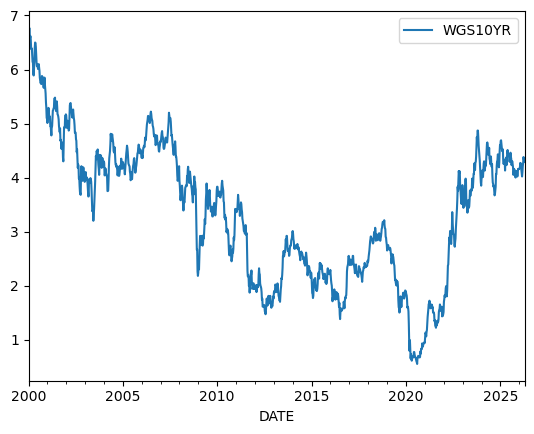

In [3]:
rate = web.DataReader(name='WGS10YR', data_source='fred', start='2000-01-01')
rate.plot()

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
device

device(type='cpu')

In [6]:
# Переведем ряда массив Numpy
series = rate.iloc[:,0].values

# scaler = MinMaxScaler()
# series = scaler.fit_predict(series)

In [7]:
series

array([6.56, 6.66, 6.77, ..., 4.33, 4.31, 4.29], shape=(1372,))

In [8]:
# задаём ширину окна и горизонт прогнозирования
n_lags, fh= 20, 10

X, y = make_datasets(series, n_inputs=n_lags, n_outputs=fh)

In [9]:
X_tensor = torch.Tensor(X).to(device)
y_tensor = torch.Tensor(y).to(device)

In [10]:
train_dataset = TensorDataset(X_tensor, y_tensor)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [12]:
model = nn.Sequential(
    nn.Linear(n_lags, 50),
    nn.ReLU(),
    # nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(50, fh)
).to(device)

In [13]:
# Обучение
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())
epochs = 100


for epoch in range(epochs):
	total_loss = 0.0
	model.train()

	for batch_X, batch_y in train_loader:
		batch_X, batch_y = batch_X.to(device), batch_y.to(device)
		predictions = model(batch_X)
		loss = criterion(predictions, batch_y)

		optimizer.zero_grad()
		loss.backward()
		optimizer.step()

		total_loss += loss.item()

	print(f"Эпоха {epoch+1}, Loss: {loss.item():.4f}")

Эпоха 1, Loss: 4.7274
Эпоха 2, Loss: 0.6976
Эпоха 3, Loss: 0.2040
Эпоха 4, Loss: 0.1813
Эпоха 5, Loss: 0.1710
Эпоха 6, Loss: 0.1198
Эпоха 7, Loss: 0.1420
Эпоха 8, Loss: 0.1764
Эпоха 9, Loss: 0.1552
Эпоха 10, Loss: 0.1562
Эпоха 11, Loss: 0.1415
Эпоха 12, Loss: 0.1101
Эпоха 13, Loss: 0.1468
Эпоха 14, Loss: 0.1557
Эпоха 15, Loss: 0.1432
Эпоха 16, Loss: 0.1285
Эпоха 17, Loss: 0.0873
Эпоха 18, Loss: 0.1090
Эпоха 19, Loss: 0.1367
Эпоха 20, Loss: 0.0888
Эпоха 21, Loss: 0.1357
Эпоха 22, Loss: 0.0980
Эпоха 23, Loss: 0.1187
Эпоха 24, Loss: 0.1206
Эпоха 25, Loss: 0.1216
Эпоха 26, Loss: 0.1297
Эпоха 27, Loss: 0.0867
Эпоха 28, Loss: 0.0943
Эпоха 29, Loss: 0.1097
Эпоха 30, Loss: 0.0835
Эпоха 31, Loss: 0.0760
Эпоха 32, Loss: 0.0855
Эпоха 33, Loss: 0.0993
Эпоха 34, Loss: 0.0938
Эпоха 35, Loss: 0.0967
Эпоха 36, Loss: 0.1073
Эпоха 37, Loss: 0.1154
Эпоха 38, Loss: 0.1335
Эпоха 39, Loss: 0.0995
Эпоха 40, Loss: 0.1177
Эпоха 41, Loss: 0.1041
Эпоха 42, Loss: 0.0864
Эпоха 43, Loss: 0.1064
Эпоха 44, Loss: 0.07

In [14]:
test_loss = 0
inputs = torch.Tensor(np.reshape(series[-n_lags:], (1, n_lags))).to(device)

model.eval()
with torch.no_grad():  # Отключаем вычисление градиентов
	# for batch in test_loader:
	outputs = model(inputs)
	# test_loss += criterion(outputs, targets)

In [15]:
y_pred = outputs.numpy()[0,]
y_pred

array([4.317484 , 4.329187 , 4.2997556, 4.315483 , 4.298386 , 4.266547 ,
       4.2988205, 4.2388964, 4.2184877, 4.2136683], dtype=float32)

In [16]:
model2 = nn.Sequential(
    nn.Linear(n_lags, 50),
    # nn.ReLU(),
    nn.Sigmoid(),
    # nn.Tanh(),
    nn.Linear(50, fh)
).to(device)

In [22]:
# размерность модели 50 дома в 30 и 15
# функция активации ReLU

In [17]:
# Обучение
criterion = nn.MSELoss()
optimizer = optim.Adam(model2.parameters())
epochs = 100


for epoch in range(epochs):
	total_loss = 0.0
	model2.train()

	for batch_X, batch_y in train_loader:
		batch_X, batch_y = batch_X.to(device), batch_y.to(device)
		predictions = model2(batch_X)
		loss = criterion(predictions, batch_y)

		optimizer.zero_grad()
		loss.backward()
		optimizer.step()

		total_loss += loss.item()

	print(f"Эпоха {epoch+1}, Loss: {loss.item():.4f}")

Эпоха 1, Loss: 7.4089
Эпоха 2, Loss: 3.5223
Эпоха 3, Loss: 2.0945
Эпоха 4, Loss: 1.2918
Эпоха 5, Loss: 0.9552
Эпоха 6, Loss: 0.8777
Эпоха 7, Loss: 0.9233
Эпоха 8, Loss: 0.8578
Эпоха 9, Loss: 0.8993
Эпоха 10, Loss: 0.6845
Эпоха 11, Loss: 0.8722
Эпоха 12, Loss: 0.7260
Эпоха 13, Loss: 0.6736
Эпоха 14, Loss: 0.7722
Эпоха 15, Loss: 0.6644
Эпоха 16, Loss: 0.7347
Эпоха 17, Loss: 0.7883
Эпоха 18, Loss: 0.6248
Эпоха 19, Loss: 0.7093
Эпоха 20, Loss: 0.6106
Эпоха 21, Loss: 0.5285
Эпоха 22, Loss: 0.4748
Эпоха 23, Loss: 0.4989
Эпоха 24, Loss: 0.5257
Эпоха 25, Loss: 0.5689
Эпоха 26, Loss: 0.4890
Эпоха 27, Loss: 0.4990
Эпоха 28, Loss: 0.4810
Эпоха 29, Loss: 0.4560
Эпоха 30, Loss: 0.4141
Эпоха 31, Loss: 0.4349
Эпоха 32, Loss: 0.4514
Эпоха 33, Loss: 0.2488
Эпоха 34, Loss: 0.2962
Эпоха 35, Loss: 0.3238
Эпоха 36, Loss: 0.3746
Эпоха 37, Loss: 0.2708
Эпоха 38, Loss: 0.2600
Эпоха 39, Loss: 0.2673
Эпоха 40, Loss: 0.1527
Эпоха 41, Loss: 0.2626
Эпоха 42, Loss: 0.1857
Эпоха 43, Loss: 0.2209
Эпоха 44, Loss: 0.16

In [18]:
test_loss = 0
inputs = torch.Tensor(np.reshape(series[-n_lags:], (1, n_lags))).to(device)

model2.eval()
with torch.no_grad():  # Отключаем вычисление градиентов
	# for batch in test_loader:
	outputs2 = model2(inputs)
	# test_loss += criterion(outputs, targets)

In [19]:
y_pred2 = outputs2.numpy()[0,]
y_pred2

array([4.3671956, 4.354654 , 4.3341193, 4.317716 , 4.325006 , 4.3092866,
       4.29968  , 4.299208 , 4.2980404, 4.28523  ], dtype=float32)

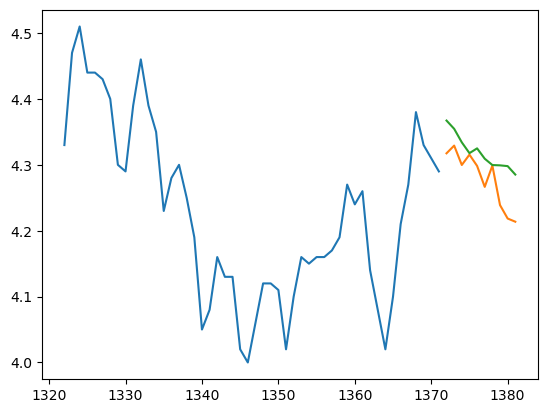

In [20]:
last_obs = 50
plt.plot(np.arange(len(series)-last_obs, len(series)), series[-last_obs:])
plt.plot(np.arange(len(series), len(series)+fh), y_pred)
plt.plot(np.arange(len(series), len(series)+fh), y_pred2)
plt.show()